### Deliverable 1: Description and Initial Data Analysis

### 1. Data Acquisition and Cleaning

In [2]:
import yfinance as yf
import pandas as pd

tickers = ["WALMEX.MX", "AC.MX", "FEMSAUBD.MX", "BIMBOA.MX", "ALSEA.MX", "AAPL", "MSFT", "AMZN", "KO", "PG"]

# Data window: 2 years ending on the current date (September 7, 2026)
start_date = "2024-08-31"
end_date = "2026-08-31"

raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
raw_data.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AC.MX,ALSEA.MX,AMZN,BIMBOA.MX,FEMSAUBD.MX,KO,MSFT,PG,WALMEX.MX
Date,,,,,,,,,,
2024-09-02,NaN,164.607086,54.153042,NaN,67.793777,183.738907,NaN,NaN,NaN,59.112640
2024-09-03,220.921951,165.154251,52.822525,176.250000,66.529579,179.069214,68.981865,403.072662,165.353516,57.841602
2024-09-04,219.017883,164.069199,52.171837,173.330002,68.507896,183.649246,68.556694,402.541046,166.661057,56.813557
2024-09-05,220.535172,166.712311,51.394890,177.889999,67.436707,181.865631,67.243385,402.039001,166.253632,56.028503
2024-09-06,218.988144,166.128052,50.462555,171.389999,66.770836,182.035950,67.215042,395.453033,166.367325,55.710747


First,we selected 10 stocks, 5 Mexican and 5 US stocks, because the firm invest in stocks both from Mexico and the US. We obtained their historical information through the API yfinance.
Something important to highlight is that the data is the adjusted closing prices, as some stocks pay dividends.
Through the function head(),  we observe the first 5 rows of values from. the stocks closing prices.

In [3]:
print(raw_data.shape)
print(raw_data.isna().sum())

(514, 10)
Ticker
AAPL           15
AC.MX          16
ALSEA.MX       16
AMZN           15
BIMBOA.MX      16
FEMSAUBD.MX    16
KO             15
MSFT           15
PG             15
WALMEX.MX      16
dtype: int64


Through the function .shape(), we can observe that the shape of the dataset is 514 rows and the 10 columns of the stocks. On the. other side, through the function .isna().sum(), we can. notice thatthere. aremany. missing values in all the columns, so we need to fix it.

In [4]:
fondo = raw_data.ffill().dropna()
fondo.index = pd.to_datetime(fondo.index)
fondo.to_csv("fondo.csv")
print("Saved fondo.csv with shape:", fondo.shape)
print(fondo.isna().sum())

Saved fondo.csv with shape: (513, 10)
Ticker
AAPL           0
AC.MX          0
ALSEA.MX       0
AMZN           0
BIMBOA.MX      0
FEMSAUBD.MX    0
KO             0
MSFT           0
PG             0
WALMEX.MX      0
dtype: int64


Trough the function .ffill(), the code replaces each NaN with the last known value for that column, we decided to do this, as if the market was closed that day, there is no new price.
Trough the function .dropna(), the code removes rows that are still NaN after ffill.
We also converted the data set into a cvs file named fondo, so we could have the data clean and ready to use.

### 2. Identification of Dependent and Independent Variables

In [5]:
returns = fondo.pct_change().dropna()
returns.to_csv("returns.csv")

fondo_return = returns.mean(axis=1)
fondo_return.name = "Fondo_Return"
fondo_return.head()

Date
2024-09-04   -0.000611
2024-09-05   -0.002756
2024-09-06   -0.009593
2024-09-09    0.009042
2024-09-10   -0.003491
Name: Fondo_Return, dtype: float64

With the function .pct_change(), we are able to convert the daily prices into daily percentage returns. In addition, through .mean(axis=1), we get the daily average of returns of the. portfolio, with the assumption that all the stocks have equal weights.

In [6]:
tech = pd.DataFrame(index=fondo_return.index)

# Lagged return (momentum, avoids leakage)
tech["Lag_Return"] = fondo_return.shift(1)

# Simple Moving Average (10-day) of the fondo's price level (equal-weighted index)
fondo_index = (1 + fondo_return).cumprod()
tech["SMA_10"] = fondo_index.rolling(window=10).mean().shift(1)

# RSI (14-day)
delta = fondo_index.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
tech["RSI_14"] = (100 - (100 / (1 + rs))).shift(1)

tech.head(20)

,Lag_Return,SMA_10,RSI_14
Date,,,
2024-09-04,NaN,NaN,NaN
2024-09-05,-0.000611,NaN,NaN
2024-09-06,-0.002756,NaN,NaN
2024-09-09,-0.009593,NaN,NaN
2024-09-10,0.009042,NaN,NaN
2024-09-11,-0.003491,NaN,NaN
2024-09-12,0.005084,NaN,NaN
2024-09-13,0.007378,NaN,NaN
2024-09-16,0.001210,NaN,NaN


In [7]:
macro_tickers = ["^GSPC", "^MXX", "^TNX"]
macro_data = yf.download(macro_tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
macro_data = macro_data.ffill().dropna()

macro_returns = macro_data.pct_change().dropna()
macro_returns.columns = ["SP500_return", "IPC_return", "Treasury10Y_change"]
macro_returns_lagged = macro_returns.shift(1)
macro_returns_lagged.columns = [c + "_lag1" for c in macro_returns_lagged.columns]

macro_returns_lagged.head()

[                       0%                       ]

[*********************100%***********************]  3 of 3 completed


,SP500_return_lag1,IPC_return_lag1,Treasury10Y_change_lag1
Date,,,
2024-09-04,NaN,NaN,NaN
2024-09-05,-0.001603,0.004302,-0.019771
2024-09-06,-0.003018,-0.002893,-0.009820
2024-09-09,-0.017260,-0.011189,-0.005628
2024-09-10,0.011580,0.001030,-0.003504


In [8]:
model_data = pd.concat([fondo_return, tech, macro_returns_lagged], axis=1)
model_data = model_data.dropna()
model_data.to_csv("model_data.csv")

print(model_data.shape)
model_data.head()

(498, 7)


,Fondo_Return,Lag_Return,SMA_10,RSI_14,SP500_return_lag1,IPC_return_lag1,Treasury10Y_change_lag1
Date,,,,,,,
2024-09-24,0.006583,0.001920,1.005270,61.236428,0.002809,0.004441,0.002951
2024-09-25,-0.003912,0.006583,1.007841,65.477590,0.002511,0.023496,-0.000802
2024-09-26,-0.000816,-0.003912,1.009509,64.181634,-0.001861,-0.008630,0.012045
2024-09-27,-0.005057,-0.000816,1.010358,74.685994,0.004039,0.007512,0.002645
2024-09-30,0.000711,-0.005057,1.010573,62.403809,-0.001253,-0.015158,-0.011079


In [9]:
import numpy as np

# Annualized volatility of the portfolio
annual_vol = fondo_return.std() * np.sqrt(252)
print(f"Annualized portfolio volatility: {annual_vol:.2%}")

# Annualized volatility per stock, for comparison
stock_vol = returns.std() * np.sqrt(252)
print(stock_vol.sort_values(ascending=False))

Annualized portfolio volatility: 12.51%
Ticker
AMZN           0.337187
ALSEA.MX       0.304463
BIMBOA.MX      0.287351
MSFT           0.284813
AAPL           0.284259
WALMEX.MX      0.260199
AC.MX          0.236134
FEMSAUBD.MX    0.225198
PG             0.188408
KO             0.177577
dtype: float64


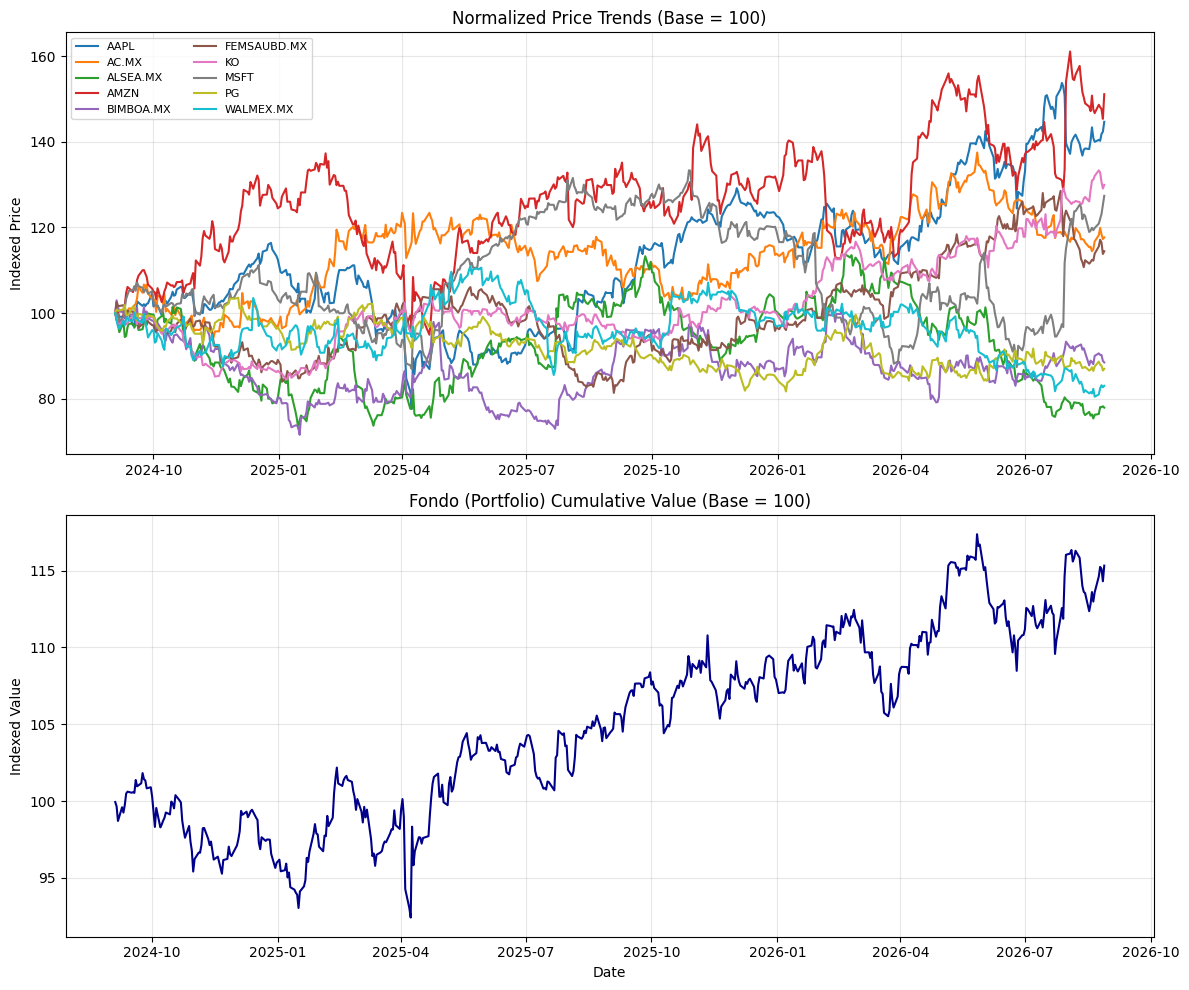

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: individual stocks
normalized_prices = fondo / fondo.iloc[0] * 100
for col in normalized_prices.columns:
    axes[0].plot(normalized_prices.index, normalized_prices[col], label=col)
axes[0].set_title("Normalized Price Trends (Base = 100)")
axes[0].set_ylabel("Indexed Price")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)

# Bottom: portfolio (fondo)
fondo_index_series = (1 + fondo_return).cumprod() * 100
axes[1].plot(fondo_index_series.index, fondo_index_series, color="darkblue")
axes[1].set_title("Fondo (Portfolio) Cumulative Value (Base = 100)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Indexed Value")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

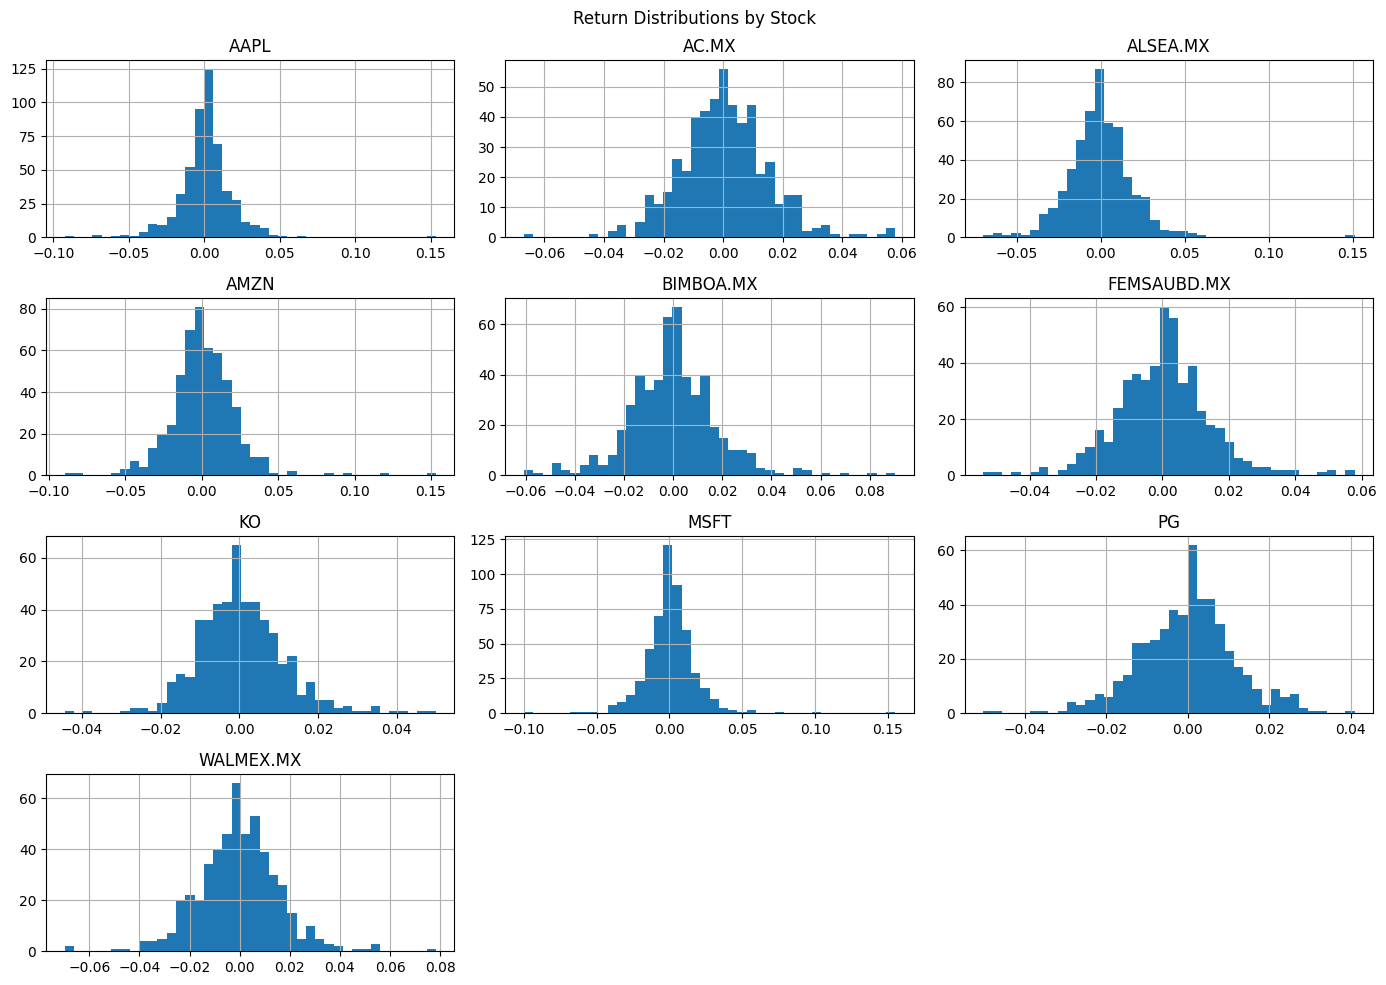

In [12]:
returns.hist(figsize=(14, 10), bins=40)
plt.suptitle("Return Distributions by Stock")
plt.tight_layout()
plt.show()

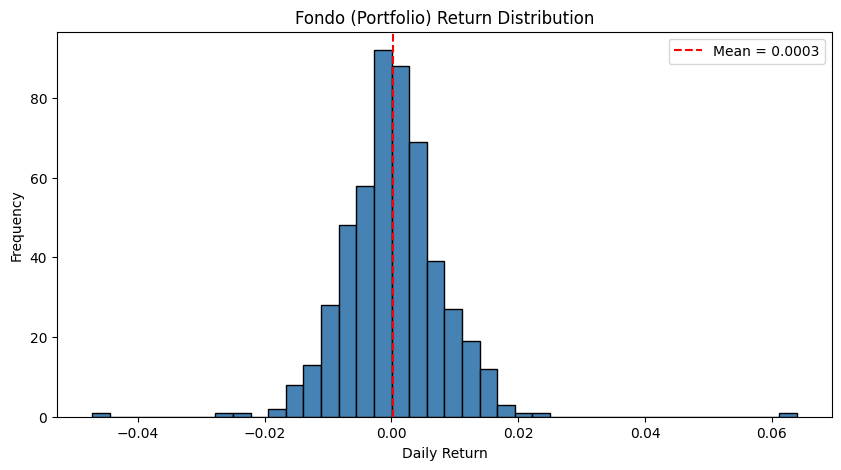

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(fondo_return, bins=40, color="steelblue", edgecolor="black")
plt.axvline(fondo_return.mean(), color="red", linestyle="--", label=f"Mean = {fondo_return.mean():.4f}")
plt.title("Fondo (Portfolio) Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()